<p align="center">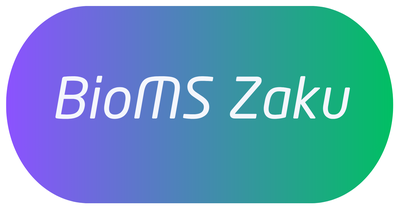</p>

# BioMS Zaku

**EN** — Run every cell (in Colab: **Runtime → Run all**). There is nothing to download: the example data travel inside the package. In about a minute you see the three things the tool does — redundancy **predicted** before any index is computed, an audit against a negative control, and the report.

**ES** — Ejecute todas las celdas (en Colab: **Entorno de ejecución → Ejecutar todo**). No hay nada que descargar: los datos de ejemplo viajan dentro del paquete. En un minuto verá las tres cosas que hace la herramienta — la redundancia **predicha** antes de calcular ningún índice, una auditoría contra un control negativo y el informe.

**PT** — Rode todas as células (no Colab: **Ambiente de execução → Executar tudo**). Não há nada a baixar: os dados de exemplo viajam dentro do pacote. Em cerca de um minuto você vê as três coisas que a ferramenta faz — a redundância **prevista** antes de qualquer índice ser calculado, uma auditoria contra um controle negativo e o relatório.

**IT** — Esegui tutte le celle (in Colab: **Runtime → Esegui tutto**). Non c'è nulla da scaricare: i dati di esempio viaggiano dentro il pacchetto. In circa un minuto vedrai le tre cose che lo strumento fa — la ridondanza **prevista** prima che qualsiasi indice sia calcolato, un audit contro un controllo negativo e il rapporto.

**EN** — The data are **synthetic**: 400 people drawn from the means and covariances of NHANES per sex × diabetes. No real person is in this file, and every number below is reproducible.

**ES** — Los datos son **sintéticos**: 400 personas extraídas de las medias y covarianzas de NHANES por sexo × diabetes. Ninguna persona real está en este archivo y todos los números de abajo son reproducibles.

**PT** — Os dados são **sintéticos**: 400 pessoas sorteadas das médias e covariâncias do NHANES por sexo × diabetes. Nenhuma pessoa real está neste arquivo e todo número abaixo é reproduzível.

**IT** — I dati sono **sintetici**: 400 persone estratte da medie e covarianze di NHANES per sesso × diabete. Nessuna persona reale è in questo file e ogni numero qui sotto è riproducibile.

In [ ]:
%pip install -q bioms-zaku

## The data come with the package · Los datos vienen con el paquete · Os dados vêm com o pacote · I dati arrivano col pacchetto

**EN** — `load_example` reads the file from inside the installed package: no download, no upload, no path to fix. Change `LANG` in the next cell and the tool — messages, figures, report — speaks that language.

**ES** — `load_example` lee el archivo desde dentro del paquete instalado: sin descarga, sin subida, sin ruta que corregir. Cambie `LANG` en la celda siguiente y la herramienta — mensajes, figuras, informe — habla ese idioma.

**PT** — `load_example` lê o arquivo de dentro do pacote instalado: sem download, sem upload, sem caminho para corrigir. Troque `LANG` na célula seguinte e a ferramenta — mensagens, figuras, relatório — fala aquela língua.

**IT** — `load_example` legge il file dall'interno del pacchetto installato: nessun download, nessun upload, nessun percorso da correggere. Cambia `LANG` nella cella seguente e lo strumento — messaggi, figure, rapporto — parla quella lingua.

In [ ]:
LANG = "en"        # en · es · pt · it

from bioms_zaku.api import load_example, set_language

set_language(LANG)
df = load_example("zaku_exemplo")
print(df.shape)
df.head()

**EN** — The columns: `R` and `Xc` are resistance and reactance (bioimpedance at 50 kHz); `H_cm` and `W` are stature and body mass; `idade` age and `sexo` sex (0 = F, 1 = M); `BMXARMC`, `BMXWAIST`, `BMXCALF` circumferences. `LMI_DXA`, `ALMI_DXA` and `FMI_DXA` are lean, appendicular lean and fat mass indices measured by DXA — the reference. `label_synthetic` is a label built from fat mass and age **only**: a known answer to check the tool against. `diabetes` is the doctor-diagnosed answer of the source survey.

**ES** — Las columnas: `R` y `Xc` son resistencia y reactancia (bioimpedancia a 50 kHz); `H_cm` y `W` estatura y masa corporal; `idade` edad y `sexo` sexo (0 = F, 1 = M); `BMXARMC`, `BMXWAIST`, `BMXCALF` perímetros. `LMI_DXA`, `ALMI_DXA` y `FMI_DXA` son índices de masa magra, magra apendicular y grasa medidos por DXA — la referencia. `label_synthetic` es una etiqueta construida **solo** con masa grasa y edad: una respuesta conocida para comprobar la herramienta. `diabetes` es la respuesta de diagnóstico médico de la encuesta de origen.

**PT** — As colunas: `R` e `Xc` são resistência e reatância (bioimpedância a 50 kHz); `H_cm` e `W` estatura e massa corporal; `idade` idade e `sexo` sexo (0 = F, 1 = M); `BMXARMC`, `BMXWAIST`, `BMXCALF` perímetros. `LMI_DXA`, `ALMI_DXA` e `FMI_DXA` são índices de massa magra, magra apendicular e gorda medidos por DXA — a referência. `label_synthetic` é um rótulo construído **só** com massa gorda e idade: uma resposta conhecida para conferir a ferramenta. `diabetes` é a resposta de diagnóstico médico da pesquisa de origem.

**IT** — Le colonne: `R` e `Xc` sono resistenza e reattanza (bioimpedenza a 50 kHz); `H_cm` e `W` statura e massa corporea; `idade` età e `sexo` sesso (0 = F, 1 = M); `BMXARMC`, `BMXWAIST`, `BMXCALF` circonferenze. `LMI_DXA`, `ALMI_DXA` e `FMI_DXA` sono indici di massa magra, magra appendicolare e grassa misurati con DXA — il riferimento. `label_synthetic` è un'etichetta costruita **solo** da massa grassa ed età: una risposta nota per verificare lo strumento. `diabetes` è la risposta di diagnosi medica dell'indagine di origine.

## 1. Redundancy predicted before anything is computed · Redundancia predicha antes de calcular nada · Redundância prevista antes de calcular nada · Ridondanza prevista prima di calcolare nulla

**EN** — An index that is a product of powers is a **vector of exponents**. Over the variables `R, Xc, H, W`: the impedance index `H²/R` is `(-1, 0, +2, 0)` and the body mass index `W/H²` is `(0, 0, -2, +1)`.

**ES** — Un índice que es un producto de potencias es un **vector de exponentes**. Sobre las variables `R, Xc, H, W`: el índice de impedancia `H²/R` es `(-1, 0, +2, 0)` y el índice de masa corporal `W/H²` es `(0, 0, -2, +1)`.

**PT** — Um índice que é produto de potências é um **vetor de expoentes**. Sobre as variáveis `R, Xc, H, W`: o índice de impedância `H²/R` é `(-1, 0, +2, 0)` e o índice de massa corporal `W/H²` é `(0, 0, -2, +1)`.

**IT** — Un indice che è un prodotto di potenze è un **vettore di esponenti**. Sulle variabili `R, Xc, H, W`: l'indice di impedenza `H²/R` è `(-1, 0, +2, 0)` e l'indice di massa corporea `W/H²` è `(0, 0, -2, +1)`.

$$\rho = \frac{a^{\top}\Sigma b}{\sqrt{a^{\top}\Sigma a \cdot b^{\top}\Sigma b}}$$

**EN** — With **Σ**, the covariance of the *logarithms* of the measured variables, the Pearson correlation of the logs of any two such indices is the expression above — an identity that holds for any distribution. Neither index has to be computed. Below, the prediction is compared with what the data show.

**ES** — Con **Σ**, la covarianza de los *logaritmos* de las variables medidas, la correlación de Pearson de los logaritmos de dos índices cualesquiera es la expresión de arriba — una identidad válida para cualquier distribución. Ningún índice necesita calcularse. Abajo se compara la predicción con lo que muestran los datos.

**PT** — Com **Σ**, a covariância dos *logaritmos* das variáveis medidas, a correlação de Pearson dos logaritmos de dois índices quaisquer é a expressão acima — uma identidade válida para qualquer distribuição. Nenhum dos índices precisa ser calculado. Abaixo, a previsão é comparada com o que os dados mostram.

**IT** — Con **Σ**, la covarianza dei *logaritmi* delle variabili misurate, la correlazione di Pearson dei logaritmi di due indici qualsiasi è l'espressione sopra — un'identità valida per qualsiasi distribuzione. Nessuno dei due indici deve essere calcolato. Sotto, la previsione è confrontata con ciò che i dati mostrano.

In [ ]:
import numpy as np
from scipy.stats import spearmanr

from bioms_zaku.algebra import log_covariance, pearson_to_spearman, predicted_pearson_log

variables = ["R", "Xc", "H_cm", "W"]
ii  = np.array([-1, 0,  2, 0])      # H² / R
bmi = np.array([ 0, 0, -2, 1])      # W / H²

for sex, label in ((0, "F"), (1, "M")):
    d = df[df.sexo == sex]
    sigma, n = log_covariance(d, variables)
    predicted = pearson_to_spearman(predicted_pearson_log(ii, bmi, sigma))
    observed = spearmanr(d.H_cm ** 2 / d.R, d.W / d.H_cm ** 2).statistic
    print(f"{label} (n={n}):  predicted {predicted:+.3f}   observed {observed:+.3f}   difference {abs(predicted - observed):.3f}")

**EN** — The prediction came from Σ alone. Now the same two indices with women and men **mixed together**:

**ES** — La predicción salió solo de Σ. Ahora los mismos dos índices con mujeres y hombres **mezclados**:

**PT** — A previsão saiu só de Σ. Agora os mesmos dois índices com mulheres e homens **misturados**:

**IT** — La previsione è venuta solo da Σ. Ora gli stessi due indici con donne e uomini **mescolati**:

In [ ]:
sigma, n = log_covariance(df, variables)
predicted = pearson_to_spearman(predicted_pearson_log(ii, bmi, sigma))
observed = spearmanr(df.H_cm ** 2 / df.R, df.W / df.H_cm ** 2).statistic
print(f"mixed (n={n}):  predicted {predicted:+.3f}   observed {observed:+.3f}")

**EN** — Half of the within-sex value — and the algebra predicts that too. Redundancy is a property of **the population**, not of the formulas: mixing two populations changes Σ, and with it every correlation. This is why everything below is computed inside a stratum and never across.

**ES** — La mitad del valor dentro de cada sexo — y el álgebra también lo predice. La redundancia es una propiedad de **la población**, no de las fórmulas: mezclar dos poblaciones cambia Σ y con ella toda correlación. Por eso todo lo de abajo se calcula dentro de un estrato y nunca entre estratos.

**PT** — Metade do valor de dentro de cada sexo — e a álgebra prevê isso também. Redundância é propriedade da **população**, não das fórmulas: misturar duas populações muda Σ e com ela toda correlação. É por isso que tudo abaixo é calculado dentro de um estrato e nunca entre estratos.

**IT** — La metà del valore entro ciascun sesso — e l'algebra prevede anche questo. La ridondanza è una proprietà della **popolazione**, non delle formule: mescolare due popolazioni cambia Σ e con essa ogni correlazione. Per questo tutto ciò che segue è calcolato dentro uno strato e mai fra strati.

## 2. The audit: does the index measure what it claims? · La auditoría: ¿el índice mide lo que dice medir? · A auditoria: o índice mede o que diz medir? · L'audit: l'indice misura ciò che dichiara?

**EN** — The question is not whether an index correlates with lean mass — almost everything does. It is whether it predicts lean mass **beyond** what a fat mass index already predicts. So the run declares, before seeing any result: target `LMI_DXA` (lean mass by DXA) and negative control `FMI_DXA` (fat mass by DXA). An index is called *specific* only when it predicts the target beyond the control, and *tracks the control* when its apparent success is explained by the control. Everything is declared in the configuration — nothing is chosen afterwards.

**ES** — La pregunta no es si un índice correlaciona con la masa magra — casi todo lo hace. Es si predice la masa magra **más allá** de lo que ya predice un índice de masa grasa. Por eso la ejecución declara, antes de ver cualquier resultado: objetivo `LMI_DXA` (masa magra por DXA) y control negativo `FMI_DXA` (masa grasa por DXA). Un índice es *específico* solo cuando predice el objetivo más allá del control, y *sigue al control* cuando su éxito aparente lo explica el control. Todo se declara en la configuración — nada se elige después.

**PT** — A pergunta não é se um índice correlaciona com massa magra — quase tudo correlaciona. É se ele prediz massa magra **além** do que um índice de massa gorda já prediz. Por isso a execução declara, antes de ver qualquer resultado: alvo `LMI_DXA` (massa magra por DXA) e controle negativo `FMI_DXA` (massa gorda por DXA). Um índice é *específico* só quando prediz o alvo além do controle, e *mede o controle* quando o sucesso aparente é explicado pelo controle. Tudo é declarado na configuração — nada é escolhido depois.

**IT** — La domanda non è se un indice correla con la massa magra — quasi tutto lo fa. È se predice la massa magra **oltre** ciò che un indice di massa grassa già predice. Per questo l'esecuzione dichiara, prima di vedere qualsiasi risultato: target `LMI_DXA` (massa magra da DXA) e controllo negativo `FMI_DXA` (massa grassa da DXA). Un indice è *specifico* solo quando predice il target oltre il controllo, e *segue il controllo* quando il successo apparente è spiegato dal controllo. Tutto è dichiarato nella configurazione — nulla è scelto dopo.

In [ ]:
from bioms_zaku.api import check, example_path, run

config = {
    "run_name": "notebook",
    "data": {
        "path": str(example_path("zaku_exemplo")),          # your own CSV goes here
        "columns": {
            "variables": {"R": "R", "Xc": "Xc", "H": "H_cm", "W": "W"},
            "units": {"H": "cm", "W": "kg"},
            "covariates": ["W", "H_cm"],
            # EN: the three circumferences are in the example file and two curated methods need them (Rsp, Xcsp):
            #     leaving them unmapped would silently reduce the catalogue from 7 evaluable methods to 5.
            "groups": {"sexo": "sexo", "idade": "idade",
                       "C_arm": "BMXARMC", "C_waist": "BMXWAIST", "C_calf": "BMXCALF"},
            "id": "id",
            "targets": {"LMI_DXA": "LMI_DXA"},
            "controls": {"FMI_DXA": "FMI_DXA"},
            "pairing": {"LMI_DXA": "FMI_DXA"},
        },
    },
    "strata": "sexo",
    "strata_labels": {0: "F", 1: "M"},
    # EN: every CURATED method — the ones whose primary source was read in the original. 7 of the 8 run on these
    #     columns; Hoffer 1969 is skipped and says why (it needs |Z| at 100 kHz, which this device does not record).
    "catalog": {"include": "curated"},
    "declarations": {
        "targets_independent_of_variables": True,           # DXA is not computed from R, Xc, H, W
        "target_kinds": {"LMI_DXA": "lean_mass", "FMI_DXA": "fat_mass"},
    },
    "preset": "quick",                                      # "full" for the publication-grade run
    "output": {"dir": "./zaku_out", "figures": True},
}

check(config)

In [ ]:
res = run(config)

## 3. The verdicts · Los veredictos · Os vereditos · I verdetti

**EN** — One row per index and stratum. `redundant`: another index already carries the same information. `specific`: it predicts the target beyond the negative control. `useful`: it adds something over body mass and stature alone.

**ES** — Una fila por índice y estrato. `redundant`: otro índice ya lleva la misma información. `specific`: predice el objetivo más allá del control negativo. `useful`: añade algo sobre masa corporal y estatura solas.

**PT** — Uma linha por índice e estrato. `redundant`: outro índice já carrega a mesma informação. `specific`: prediz o alvo além do controle negativo. `useful`: acrescenta algo sobre massa corporal e estatura sozinhas.

**IT** — Una riga per indice e strato. `redundant`: un altro indice porta già la stessa informazione. `specific`: predice il target oltre il controllo negativo. `useful`: aggiunge qualcosa oltre massa corporea e statura da sole.

In [ ]:
import pandas as pd

pd.read_csv(f"{res['out_dir']}/screening.csv")

## 4. The tool proposes new indices · La herramienta propone nuevos índices · A ferramenta propõe índices novos · Lo strumento propone nuovi indici

**EN** — The audit above judged what already exists. This is the other direction: from the SAME data the tool fits the exponents of R, Xc, H and W to the target by least squares on 70 % of the rows of each stratum, and audits the index it built on the other 30 %, never seen — like any published method, and marked △. The design is not a shortcut past the audit: it produces a candidate and then has to survive the same negative control. `expr` below is yours to change: any formula you write enters the same run beside the published methods, marked ◇, with no DOI and never precedence over a publication.

**ES** — La auditoría anterior juzgó lo que ya existe. Esta es la otra dirección: con los MISMOS datos la herramienta ajusta los exponentes de R, Xc, H y W al objetivo por mínimos cuadrados en el 70 % de las filas de cada estrato, y audita el índice que construyó en el otro 30 %, nunca visto — como cualquier método publicado, y marcado △. El diseño no es un atajo que evite la auditoría: produce un candidato que luego debe sobrevivir al mismo control negativo. El `expr` de abajo es suyo: cualquier fórmula que escriba entra en la misma ejecución junto a los métodos publicados, marcada ◇, sin DOI y sin precedencia sobre una publicación.

**PT** — A auditoria acima julgou o que já existe. Esta é a outra direção: dos MESMOS dados a ferramenta ajusta os expoentes de R, Xc, H e W ao alvo por mínimos quadrados em 70 % das linhas de cada estrato, e audita o índice que ela construiu nos outros 30 %, nunca vistos — como qualquer método publicado, e marcado △. O desenho não é atalho que pule a auditoria: ele produz um candidato, que depois tem de sobreviver ao mesmo controle negativo. O `expr` abaixo é seu: qualquer fórmula que você escrever entra na mesma execução ao lado dos métodos publicados, marcada ◇, sem DOI e sem nunca ter precedência sobre uma publicação.

**IT** — L'audit sopra ha giudicato ciò che già esiste. Questa è l'altra direzione: dagli STESSI dati lo strumento adatta gli esponenti di R, Xc, H e W al target ai minimi quadrati sul 70 % delle righe di ogni strato, e verifica l'indice che ha costruito sul restante 30 %, mai visto — come qualsiasi metodo pubblicato, e marcato △. Il disegno non è una scorciatoia che evita l'audit: produce un candidato che poi deve sopravvivere allo stesso controllo negativo. L'`expr` qui sotto è tuo: qualsiasi formula tu scriva entra nella stessa esecuzione accanto ai metodi pubblicati, marcata ◇, senza DOI e senza mai precedenza su una pubblicazione.

In [ ]:
import copy

config2 = copy.deepcopy(config)
config2["run_name"] = "proposals"
config2["design"] = [{"target": "LMI_DXA", "id": "Zaku_LMI"}]        # the tool builds an index for the target
config2["catalog"] = {
    "include": ["curated", "my_index"],                              # the curated methods PLUS your formula
    "user_entries": [{
        "id": "my_index",
        "label": "H²·Xc/R (proposed)",
        "authors": "you",
        "target": "lean_mass",                                       # what it intends to measure
        "expr": "H**2 * Xc / R",                                     # <- write your own formula here
        "provenance": {"formula_source": "proposed"},
    }],
}

res2 = run(config2)

**EN** — The exponents the tool fitted, and the verdict each new index earned out of sample. `designed` marks the index the tool built (△); the proposed formula (◇) sits beside it and beside the published methods, judged by the same rule. On this example the designed index hits the target's own direction almost exactly (cos_Σ ≈ 0.999 in the geometry table) and STILL does not come out specific — the tool refusing its own proposal. The Geometry block of the report says why in one number: the flag COUPLED_TARGET_CONTROL is lit, because lean and fat index come from one DXA scan and point nearly the same way in the measured space, so pointing at the target IS pointing at the control. That is the whole framework working on itself, and it is why the design is audited and not trusted.

**ES** — Los exponentes ajustados y el veredicto que cada índice nuevo obtuvo fuera de muestra. `designed` marca el índice construido por la herramienta (△); la fórmula propuesta (◇) está al lado, juzgada por la misma regla. En este ejemplo el índice diseñado alcanza casi exactamente la dirección del objetivo (cos_Σ ≈ 0,999) y AUN ASÍ no sale específico — la herramienta rechazando su propia propuesta. El bloque de Geometría del informe dice por qué: la bandera COUPLED_TARGET_CONTROL está encendida, porque los índices de masa magra y de grasa vienen de un mismo DXA y apuntan casi en la misma dirección, así que apuntar al objetivo ES apuntar al control.

**PT** — Os expoentes que a ferramenta ajustou, e o veredito que cada índice novo recebeu fora da amostra. `designed` marca o índice que ela construiu (△); a fórmula proposta (◇) fica ao lado, julgada pela mesma regra. Neste exemplo o índice desenhado acerta quase exatamente a direção do alvo (cos_Σ ≈ 0,999) e MESMO ASSIM não sai específico — a ferramenta recusando a própria proposta. O bloco de Geometria do relatório diz por quê: a bandeira COUPLED_TARGET_CONTROL está acesa, porque o índice de massa magra e o de gordura vêm do mesmo exame de DXA e apontam quase na mesma direção, então apontar para o alvo É apontar para o controle.

**IT** — Gli esponenti adattati e il verdetto che ogni nuovo indice ha ottenuto fuori campione. `designed` marca l'indice costruito dallo strumento (△); la formula proposta (◇) gli sta accanto, giudicata dalla stessa regola. In questo esempio l'indice disegnato coglie quasi esattamente la direzione del target (cos_Σ ≈ 0,999) e COMUNQUE non esce specifico — lo strumento che rifiuta la propria proposta. Il blocco Geometria del rapporto dice perché: la bandiera COUPLED_TARGET_CONTROL è accesa, perché indice di massa magra e di grasso vengono dallo stesso esame DXA e puntano quasi nella stessa direzione, quindi puntare al target È puntare al controllo.

In [ ]:
novos = pd.read_csv(f"{res2['out_dir']}/algebra.csv")
novos = novos[novos["method_id"].isin(["Zaku_LMI", "my_index"])]
display(novos[["method_id", "stratum", "vector_source", "fit_r2", "e_R", "e_Xc", "e_H", "e_W"]])

vereditos = pd.read_csv(f"{res2['out_dir']}/screening.csv")
vereditos[vereditos["method_id"].isin(["Zaku_LMI", "my_index"])]

## 5. The report, and your own data · El informe y sus propios datos · O relatório e os seus próprios dados · Il rapporto e i tuoi dati

**EN** — `report.html` in the output folder holds every number above with the method text beside it — how it was computed, how to read it, what rigor was applied — and a download for every table. It is one file: send it, archive it, cite it. To read a finished run in another language without recomputing anything, call `render(res["out_dir"], "pt")`. For your own data, point `config["data"]["path"]` at your CSV and edit the column names above, or let the tool ask you in a terminal: `bioms-zaku start data.csv`. What the tool guarantees, and under which assumptions, is written in `CONTRACTS.md`.

**ES** — `report.html` en la carpeta de salida tiene todos los números de arriba con el texto del método al lado — cómo se calculó, cómo leerlo, qué rigor se aplicó — y una descarga por tabla. Es un solo archivo: envíelo, archívelo, cítelo. Para leer una ejecución terminada en otro idioma sin recalcular nada, llame a `render(res["out_dir"], "pt")`. Para sus propios datos, apunte `config["data"]["path"]` a su CSV y edite los nombres de columna de arriba, o deje que la herramienta le pregunte en un terminal: `bioms-zaku start mis_datos.csv`. Lo que la herramienta garantiza, y bajo qué supuestos, está en `CONTRACTS.md`.

**PT** — `report.html` na pasta de saída tem todo número acima com o texto do método ao lado — como foi calculado, como ler, que rigor foi aplicado — e um download por tabela. É um arquivo só: mande por e-mail, arquive, cite. Para ler uma execução terminada em outra língua sem recalcular nada, chame `render(res["out_dir"], "pt")`. Para os seus próprios dados, aponte `config["data"]["path"]` para o seu CSV e edite os nomes de coluna acima, ou deixe a ferramenta perguntar num terminal: `bioms-zaku start meus_dados.csv`. O que a ferramenta garante, e sob quais pressupostos, está no `CONTRACTS.md`.

**IT** — `report.html` nella cartella di output contiene ogni numero sopra con il testo del metodo accanto — come è stato calcolato, come leggerlo, quale rigore è stato applicato — e un download per ogni tabella. È un unico file: invialo, archivialo, citalo. Per leggere un'esecuzione finita in un'altra lingua senza ricalcolare nulla, chiama `render(res["out_dir"], "pt")`. Per i tuoi dati, punta `config["data"]["path"]` al tuo CSV e modifica i nomi delle colonne sopra, oppure lascia che lo strumento ti interroghi in un terminale: `bioms-zaku start miei_dati.csv`. Ciò che lo strumento garantisce, e sotto quali ipotesi, è in `CONTRACTS.md`.

## 6. Opening the report in Colab · Abrir el informe en Colab · Abrir o relatório no Colab · Aprire il rapporto in Colab

**EN** — In Colab the file lives on a machine in Google's cloud, not on yours: there is no desktop to double-click and no terminal, so the line the tool prints at the end of a run (`xdg-open ...`) has nothing to open. Uncomment the cell below and run it: the browser downloads `report.html` and you open it with a double-click, as a normal file. The same by hand: the folder icon on the left of Colab, then `zaku_out` → `notebook` → the three dots on `report.html` → Download. Running a notebook on your own machine, ignore this cell and open the file directly.

**ES** — En Colab el archivo está en una máquina en la nube de Google, no en la suya: no hay escritorio para hacer doble clic ni terminal, así que la línea que la herramienta imprime al terminar (`xdg-open ...`) no tiene qué abrir. Descomente la celda de abajo y ejecútela: el navegador descarga `report.html` y usted lo abre con doble clic, como un archivo normal. Lo mismo a mano: el icono de carpeta a la izquierda de Colab, luego `zaku_out` → `notebook` → los tres puntos en `report.html` → Download. En su propia máquina, ignore esta celda.

**PT** — No Colab o arquivo está numa máquina na nuvem do Google, não na sua: não há área de trabalho para dar dois cliques nem terminal, então a linha que a ferramenta imprime ao terminar (`xdg-open ...`) não tem o que abrir. Descomente a célula abaixo e rode: o navegador baixa o `report.html` e você abre com dois cliques, como um arquivo qualquer. O mesmo na mão: ícone de pasta à esquerda do Colab, depois `zaku_out` → `notebook` → os três pontinhos no `report.html` → Download. Rodando o notebook na sua própria máquina, ignore esta célula.

**IT** — In Colab il file si trova su una macchina nel cloud di Google, non sulla tua: non c'è un desktop su cui fare doppio clic né un terminale, quindi la riga che lo strumento stampa alla fine (`xdg-open ...`) non ha nulla da aprire. Decommenta la cella qui sotto ed eseguila: il browser scarica `report.html` e lo apri con un doppio clic, come un file qualsiasi. Lo stesso a mano: icona della cartella a sinistra in Colab, poi `zaku_out` → `notebook` → i tre puntini su `report.html` → Download. Sulla tua macchina, ignora questa cella.

In [ ]:
# EN: Colab only — remove the # from the two lines below and run the cell.
# from google.colab import files
# files.download(f"{res['out_dir']}/report.html")